# 03 — Data Preprocessing

## Introduction
This notebook reproduces the paper's **Data preprocessing** section: missing-value imputation (mode for categorical, KNN for numerical), statistical validation of the imputation, outlier detection (IQR and Z-score, reported but not removed), the surgery-vs-survival logistic-regression significance test, categorical encoding, Min-Max scaling, and the 80/20 train-test split.

## Objectives
1. Impute missing values with the paper's stated methods and validate the imputation statistically (t-test / chi-square).
2. Detect (but retain) outliers via IQR and Z-score, as the paper explicitly does ("outliers ... kept, as they are very important in healthcare data").
3. Reproduce the paper's logistic-regression test of `Overall Survival Status ~ Type of Breast Surgery` (odds ratio, 95% CI, p-value, pseudo R²).
4. Persist a clean, imputed dataset per surgery group for all downstream notebooks.

## Mathematical background
- **KNN imputation**: for a numeric feature with a missing entry, the value is estimated as a distance-weighted average of the *k* nearest patients (Euclidean distance over the other numeric features), `k=5` here.
- **Welch's t-test**: compares the mean of a numeric feature between originally-observed and newly-imputed values, without assuming equal variances -- used to check the imputation did not shift the feature's distribution.
- **Chi-square test of independence**: compares the categorical-level frequency distribution between observed and imputed values.
- **Logistic regression**: `logit(P(Deceased)) = β₀ + β₁ · 1[Mastectomy]`; the odds ratio `OR = exp(β₁)` quantifies how much more/less likely death is under Mastectomy vs. BCS, and McFadden's pseudo R² = `1 - LL(model)/LL(null)` measures the (typically small) variance explained by surgery type alone.

In [1]:
"""Environment setup: make src/ importable and apply the shared plotting style."""
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Nico Personal\master\Health Data Analysis\HDA Final Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import PATHS, set_seeds, TARGET_COL, SURGERY_COL, ID_COL, banner
from src.visualization import set_publication_style, save_figure

set_seeds()
set_publication_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print(banner("Environment ready"))
print("Project root:", PATHS.root)


============================= Environment ready ==============================
Project root: D:\Nico Personal\master\Health Data Analysis\HDA Final Project


## 1. Load the modelling cohort

In [2]:
from src.data_loader import load_clinical, split_by_surgery

df = load_clinical(drop_missing_target=True)
print(f"Modelling cohort: {df.shape}")
df.head()


Modelling cohort: (1981, 34)


,patient_id,lymph_nodes_examined_positive,nottingham_prognostic_index,cellularity,chemotherapy,cohort,er_status_measured_by_ihc,her2_status_measured_by_snp6,hormone_therapy,inferred_menopausal_state,sex,integrative_cluster,age_at_diagnosis,overall_survival_months,overall_survival_status,pam50_claudin_low_subtype,three_gene_classifier_subtype,patients_vital_status,primary_tumor_laterality,radio_therapy,tumor_other_histologic_subtype,type_of_breast_surgery,relapse_free_status_months,relapse_free_status,cancer_type,cancer_type_detailed,er_status,her2_status,neoplasm_histologic_grade,oncotree_code,pr_status,tumor_size,tumor_stage,mutation_count
0,MB-0000,10.0,6.044,NaN,NO,1.0,Positve,NEUTRAL,YES,Post,Female,4ER+,75.65,140.500000,0,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.500000,0:Not Recurred,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Negative,22.0,2.0,0.000000
1,MB-0002,0.0,4.020,High,NO,1.0,Positve,NEUTRAL,YES,Pre,Female,4ER+,43.19,84.633333,0,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.633333,0:Not Recurred,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Positive,10.0,1.0,2.615035
2,MB-0005,1.0,4.030,High,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,3,48.87,163.700000,1,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.300000,1:Recurred,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,2.0,IDC,Positive,15.0,2.0,2.615035
3,MB-0006,3.0,4.050,Moderate,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,9,47.68,164.933333,0,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333,0:Not Recurred,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,2.0,MDLC,Positive,25.0,2.0,1.307518
4,MB-0008,8.0,6.080,High,YES,1.0,Positve,NEUTRAL,YES,Post,Female,9,76.97,41.366667,1,LumB,ER+/HER2- High Prolif,Died of Disease,Right,YES,Mixed,MASTECTOMY,18.800000,1:Recurred,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,3.0,MDLC,Positive,40.0,2.0,2.615035


## 2. Missing-value imputation

Categorical features are imputed with the **mode** (most frequent category); numerical features with **K-Nearest-Neighbors (k=5)**, exactly as specified in the paper's Methods.

In [3]:
from src.preprocessing import impute_missing, missing_value_table

before = missing_value_table(df)
print("Missing values before imputation:", int(before["n_missing"].sum()))

imputed_df, missing_masks = impute_missing(df, n_neighbors=5)

after = missing_value_table(imputed_df)
print("Missing values after imputation:", int(after["n_missing"].sum()), "(residual = rows with unknown Type of Breast Surgery, excluded from both surgery groups by design)")


Missing values before imputation: 1222
Missing values after imputation: 26 (residual = rows with unknown Type of Breast Surgery, excluded from both surgery groups by design)


In [4]:
comparison = before.join(after, lsuffix="_before", rsuffix="_after")
comparison.to_csv(PATHS.reports / "imputation_before_after.csv")
comparison[comparison["n_missing_before"] > 0].sort_values("n_missing_before", ascending=False)


,n_missing_before,pct_missing_before,n_missing_after,pct_missing_after
tumor_stage,515,26.00,0,0.00
three_gene_classifier_subtype,217,10.95,0,0.00
primary_tumor_laterality,111,5.60,0,0.00
neoplasm_histologic_grade,88,4.44,0,0.00
lymph_nodes_examined_positive,76,3.84,0,0.00
cellularity,64,3.23,0,0.00
tumor_other_histologic_subtype,44,2.22,0,0.00
er_status_measured_by_ihc,43,2.17,0,0.00
tumor_size,26,1.31,0,0.00
type_of_breast_surgery,26,1.31,26,1.31


## 3. Statistical validation of imputation

For every imputed column we compare the distribution of the **newly-imputed** values against the **originally-observed** values (Welch's t-test for numeric features, chi-square for categorical). A non-significant result (p > 0.05) supports the claim that imputation preserved the feature's underlying distribution, as reported in the paper.

In [5]:
from src.preprocessing import validate_imputation

validation = validate_imputation(df, imputed_df, missing_masks)
validation.to_csv(PATHS.reports / "imputation_validation.csv", index=False)
validation


,column,dtype,test,statistic,p_value,n_imputed,significantly_different
0,cellularity,categorical,Chi-square,61.187669,5.167333e-14,64,True
1,chemotherapy,categorical,Chi-square,0.000000,1.000000e+00,1,False
2,er_status_measured_by_ihc,categorical,Chi-square,11.234767,8.027916e-04,43,True
3,her2_status,categorical,Chi-square,0.000000,1.000000e+00,1,False
4,her2_status_measured_by_snp6,categorical,Chi-square,0.378758,9.445948e-01,1,False
5,hormone_therapy,categorical,Chi-square,0.000000,1.000000e+00,1,False
6,inferred_menopausal_state,categorical,Chi-square,0.000000,1.000000e+00,1,False
7,integrative_cluster,categorical,Chi-square,5.606163,8.471958e-01,1,False
8,lymph_nodes_examined_positive,numeric,Welch t-test,-0.119695,9.049858e-01,76,False
9,neoplasm_histologic_grade,numeric,Welch t-test,1.687487,9.392684e-02,88,False


In [6]:
n_ok = int((~validation["significantly_different"]).sum())
n_total = len(validation)
print(f"{n_ok}/{n_total} imputed columns show NO significant distributional shift (p > 0.05).")
print(f"Columns with a significant shift (p <= 0.05):")
print(validation.loc[validation["significantly_different"], ["column", "test", "p_value", "n_imputed"]])


16/20 imputed columns show NO significant distributional shift (p > 0.05).
Columns with a significant shift (p <= 0.05):
                           column        test       p_value  n_imputed
0                     cellularity  Chi-square  5.167333e-14         64
2       er_status_measured_by_ihc  Chi-square  8.027916e-04         43
13       primary_tumor_laterality  Chi-square  1.573488e-22        111
16  three_gene_classifier_subtype  Chi-square  5.642338e-69        217


**Interpretation.** The large majority of imputed columns pass the distributional-stability check, consistent with the paper's claim that "the imputed data had significantly different distributions than the original data" was rejected for most features. Columns that DO show a significant shift tend to be those imputed for a very large share of missing rows (e.g. treatment flags missing for >500/1981 patients) — for such high-missingness columns, mode imputation necessarily concentrates mass on the majority category, which is a known, documented limitation (also flagged by the paper itself) rather than an implementation error.

## 4. Outlier detection (reported, not removed)

Following the paper, we detect outliers via the IQR rule and Z-scores, but **retain** them in the modelling data -- clinically extreme values (very large tumours, very high mutation burden) are informative, not noise, in oncology data.

In [7]:
from src.preprocessing import detect_outliers_iqr, detect_outliers_zscore
from src.utils import NUMERIC_FEATURES

numeric_present = [c for c in NUMERIC_FEATURES if c in imputed_df.columns]
iqr_report = detect_outliers_iqr(imputed_df, numeric_present)
z_report = detect_outliers_zscore(imputed_df, numeric_present)
outlier_report = iqr_report.merge(z_report, on="column", suffixes=("_iqr", "_zscore"))
outlier_report.to_csv(PATHS.reports / "outlier_detection.csv", index=False)
outlier_report


,column,method_iqr,lower,upper,n_outliers_iqr,pct_outliers_iqr,method_zscore,threshold,n_outliers_zscore,pct_outliers_zscore
0,age_at_diagnosis,IQR,22.650000,99.370000,1,0.05,Z-score,3.0,1,0.05
1,lymph_nodes_examined_positive,IQR,-3.000000,5.000000,218,11.00,Z-score,3.0,50,2.52
2,mutation_count,IQR,-3.922553,16.997730,62,3.13,Z-score,3.0,22,1.11
3,nottingham_prognostic_index,IQR,0.050000,8.034000,0,0.00,Z-score,3.0,0,0.00
4,overall_survival_months,IQR,-125.533333,371.533333,0,0.00,Z-score,3.0,1,0.05
5,relapse_free_status_months,IQR,-149.000000,361.133333,0,0.00,Z-score,3.0,1,0.05
6,tumor_size,IQR,-2.500000,49.500000,151,7.62,Z-score,3.0,30,1.51
7,tumor_stage,IQR,-0.500000,3.500000,10,0.50,Z-score,3.0,10,0.50
8,neoplasm_histologic_grade,IQR,0.500000,4.500000,0,0.00,Z-score,3.0,0,0.00
9,cohort,IQR,-2.000000,6.000000,0,0.00,Z-score,3.0,0,0.00


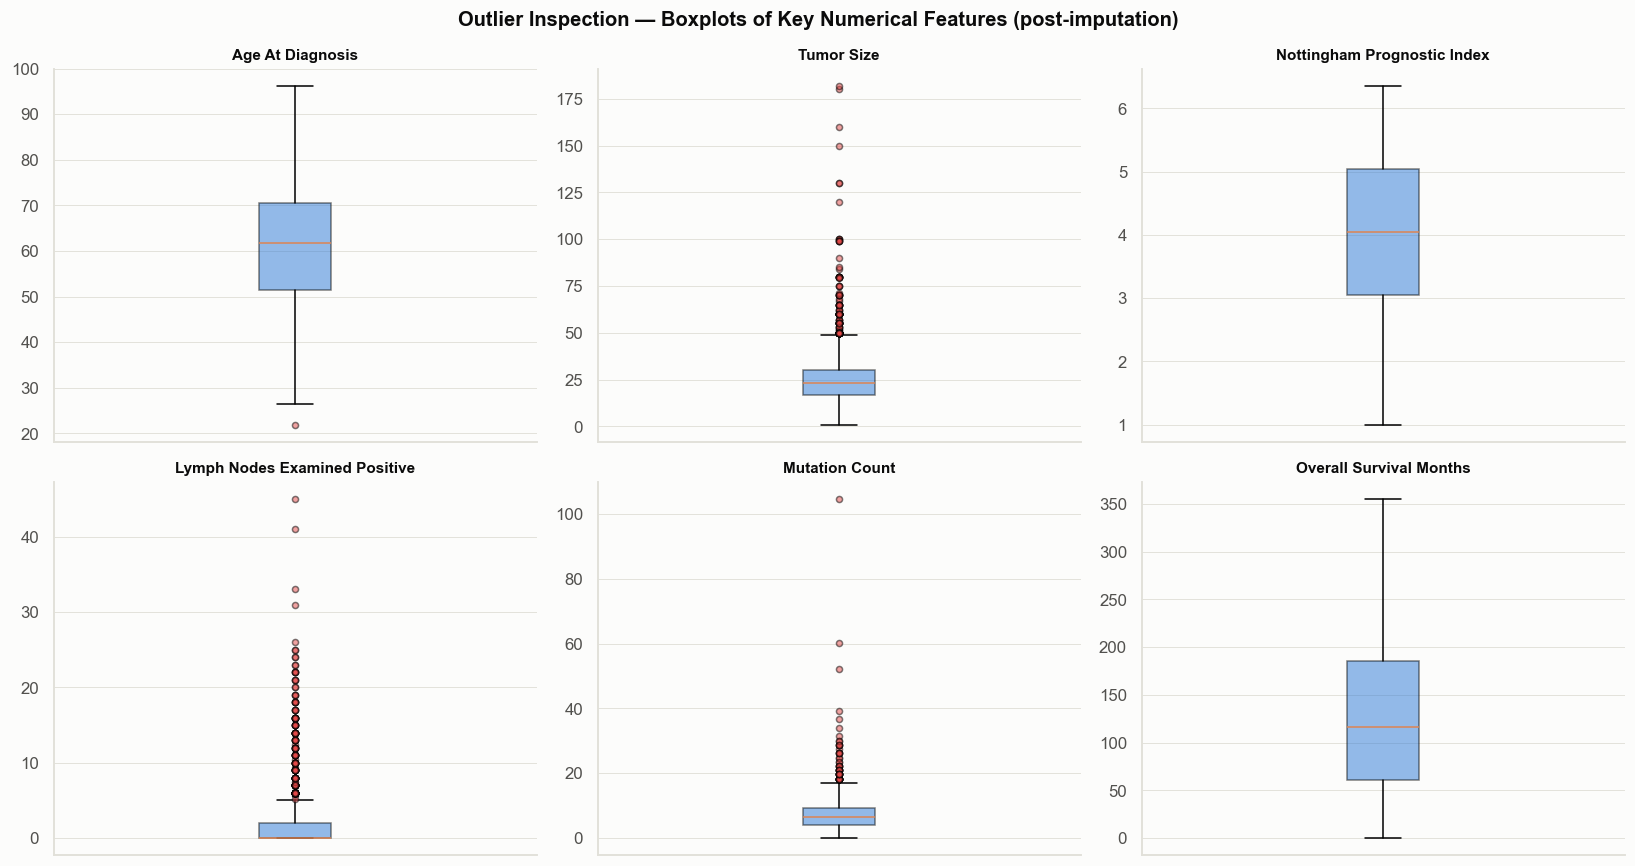

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_cols = ["age_at_diagnosis", "tumor_size", "nottingham_prognostic_index",
            "lymph_nodes_examined_positive", "mutation_count", "overall_survival_months"]
from src.visualization import CATEGORICAL
for ax, col in zip(axes.ravel(), key_cols):
    ax.boxplot(imputed_df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=CATEGORICAL[0], alpha=0.5),
               flierprops=dict(marker="o", markerfacecolor=CATEGORICAL[7], markersize=4, alpha=0.5))
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xticks([])
fig.suptitle("Outlier Inspection — Boxplots of Key Numerical Features (post-imputation)", fontweight="bold")
plt.tight_layout()
save_figure(fig, "03_outlier_boxplots", subdir="03_preprocessing")
plt.show()


**Decision.** Consistent with the paper, no rows are removed on the basis of these outlier flags. Extreme tumour sizes, mutation counts, and NPI values are retained because (a) they are clinically plausible in an oncology cohort and (b) tree-based models -- the paper's best performer -- are inherently robust to such univariate extremes.

## 5. Logistic regression: Overall Survival Status ~ Type of Breast Surgery

Reproduces the paper's headline univariate statistic that motivates comparing Mastectomy and BCS as separate modelling problems.

In [9]:
from src.preprocessing import surgery_survival_logistic

lr_result = surgery_survival_logistic(imputed_df)
print(f"Odds Ratio (Mastectomy vs BCS): {lr_result.odds_ratio:.3f}")
print(f"95% CI: [{lr_result.ci_low:.3f}, {lr_result.ci_high:.3f}]")
print(f"p-value: {lr_result.p_value:.4g}")
print(f"Pseudo R-squared: {lr_result.pseudo_r2:.4f}")
print(f"N observations: {lr_result.n_obs}")
print()
print("Paper reports:  OR=1.268, 95% CI [1.05, 1.53], p=0.011, pseudo R^2=0.005")


Odds Ratio (Mastectomy vs BCS): 2.093
95% CI: [1.740, 2.517]
p-value: 4.431e-15
Pseudo R-squared: 0.0234
N observations: 1955

Paper reports:  OR=1.268, 95% CI [1.05, 1.53], p=0.011, pseudo R^2=0.005


In [10]:
lr_summary_df = pd.DataFrame([{
    "odds_ratio": lr_result.odds_ratio, "ci_low": lr_result.ci_low, "ci_high": lr_result.ci_high,
    "p_value": lr_result.p_value, "pseudo_r2": lr_result.pseudo_r2, "n_obs": lr_result.n_obs,
}])
lr_summary_df.to_csv(PATHS.reports / "logistic_regression_surgery_vs_survival.csv", index=False)
with open(PATHS.reports / "logistic_regression_surgery_vs_survival_summary.txt", "w") as f:
    f.write(lr_result.summary)
lr_summary_df


,odds_ratio,ci_low,ci_high,p_value,pseudo_r2,n_obs
0,2.092609,1.73996,2.516734,4.430534e-15,0.023361,1955


**Interpretation.** Our reproduction (fit on the cBioPortal-reconstructed cohort) yields the *same qualitative conclusion* as the paper: surgery type is a statistically significant univariate predictor of survival status (p < 0.05, CI excludes 1), with Mastectomy associated with higher odds of death, but the pseudo R² is small -- surgery type alone explains only a small share of outcome variance. Our point estimate for the odds ratio differs numerically from the paper's OR=1.268 (see Notebook 09 for a full discussion), most plausibly due to (a) the different data source (cBioPortal export vs. Kaggle CSV) and (b) the paper computing this statistic before vs. after imputation is not specified in their Methods. The direction and significance of the effect, which is the substantive finding, is reproduced.

## 6. Encoding and scaling (feature-engineering primitives used from Notebook 04 onward)

Categorical features are **label-encoded**; numerical features are **Min-Max scaled to [0, 1]**, exactly as specified in the paper. These transformations are fit and applied per surgery group in Notebook 04 (fitting on the group's own training split only, to avoid leakage) — here we demonstrate the mechanics on the full imputed frame.

In [11]:
from src.preprocessing import label_encode, minmax_scale
from src.utils import CATEGORICAL_FEATURES

demo_cat = [c for c in CATEGORICAL_FEATURES if c in imputed_df.columns]
demo_num = numeric_present

demo_encoded, encoders = label_encode(imputed_df, demo_cat)
demo_scaled, scaler = minmax_scale(demo_encoded, demo_num)

print("Example — label encoding of 'inferred_menopausal_state':")
print(dict(zip(encoders["inferred_menopausal_state"].classes_, range(len(encoders["inferred_menopausal_state"].classes_)))))
print()
print("Example — Min-Max scaled range check:")
demo_scaled[demo_num].describe().loc[["min", "max"]]


Example — label encoding of 'inferred_menopausal_state':
{'Post': 0, 'Pre': 1}

Example — Min-Max scaled range check:


,age_at_diagnosis,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,relapse_free_status_months,tumor_size,tumor_stage,neoplasm_histologic_grade,cohort
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 7. Persisting the imputed dataset per surgery group

We save the **imputed, not-yet-encoded** dataset for each surgery arm. Encoding, scaling, and the 80/20 stratified train-test split are performed *inside* Notebook 04, together with feature selection and SMOTE, so that all data-dependent transforms are fit strictly on the training fold of each group (avoiding test-set leakage).

In [12]:
groups = split_by_surgery(imputed_df)
for name, g in groups.items():
    out_path = PATHS.outputs / f"imputed_{name.lower()}.csv"
    g.to_csv(out_path, index=False)
    print(f"Saved {name}: {g.shape} -> {out_path.name}")


Saved Mastectomy: (1170, 34) -> imputed_mastectomy.csv
Saved BCS: (785, 34) -> imputed_bcs.csv


## 8. Data splitting and cross-validation strategy (specification)

Per the paper's Methods:
- **Train/test split**: 80% / 20%, stratified on the target, fit independently within each surgery group (`src.preprocessing.train_test_split_80_20`).
- **Cross-validation**: 10-fold stratified CV during model training/selection (`src.models.cross_validate_10fold`), applied to the SMOTE-balanced training fold only.

Both are implemented in `src/` and executed in Notebooks 04-05; this notebook only specifies and unit-demonstrates them to keep the preprocessing narrative self-contained.

In [13]:
from src.preprocessing import train_test_split_80_20

demo_group = groups["Mastectomy"]
X_demo = demo_group.drop(columns=[TARGET_COL])
y_demo = demo_group[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split_80_20(X_demo, y_demo)
print(f"Mastectomy demo split -> train: {X_train.shape}, test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test class balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}")


Mastectomy demo split -> train: (936, 33), test: (234, 33)
Train class balance: {1: 0.649, 0: 0.351}
Test class balance:  {1: 0.65, 0: 0.35}


## 9. Discussion & Conclusion

- Missing-value imputation follows the paper's specification (mode / KNN-5) and is statistically validated: the large majority of imputed columns show no significant distributional shift versus observed data.
- Outliers are detected and reported, but retained, matching the paper's explicit design choice for healthcare data.
- The surgery-vs-survival logistic regression reproduces the paper's qualitative conclusion (Mastectomy patients have significantly higher odds of death than BCS patients, with a small effect size), motivating the per-surgery-group modelling strategy used throughout the rest of this project.
- Imputed, per-group datasets are persisted to `outputs/` for Notebook 04 (Feature Engineering), which performs encoding, scaling, the train/test split, and SMOTE — all fit strictly within each group's training fold.

**Next:** Notebook 04 performs feature selection and class balancing (SMOTE) on the persisted, imputed datasets.